In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install grad-cam -q


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import warnings
warnings.filterwarnings('ignore')

# Check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [4]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
print("GradCAM imported successfully")

GradCAM imported successfully


In [5]:
import zipfile
import os

# Unzip the dataset
zip_path = '/content/drive/MyDrive/archive.zip'
extract_path = '/content/PlantVillage'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipped successfully")

# See what's inside
for folder in os.listdir(extract_path):
    print(folder)

Unzipped successfully
tomato_only
plantvillage
PlantVillage


In [6]:
import os

base = '/content/PlantVillage'

for root, dirs, files in os.walk(base):
    level = root.replace(base, '').count(os.sep)
    if level < 3:
        print(f"{'  ' * level}{os.path.basename(root)}/")

PlantVillage/
  tomato_only/
    Tomato_Spider_mites_Two_spotted_spider_mite/
    Tomato_Late_blight/
    Tomato_Leaf_Mold/
    Tomato_Early_blight/
    Tomato__Target_Spot/
    Tomato_healthy/
    Tomato_Bacterial_spot/
    Tomato__Tomato_YellowLeaf__Curl_Virus/
    Tomato__Tomato_mosaic_virus/
    Tomato_Septoria_leaf_spot/
  plantvillage/
    PlantVillage/
  PlantVillage/
    Tomato_Spider_mites_Two_spotted_spider_mite/
    Tomato_Late_blight/
    Tomato_Leaf_Mold/
    Potato___Early_blight/
    Tomato_Early_blight/
    Tomato__Target_Spot/
    Potato___healthy/
    Pepper__bell___healthy/
    Tomato_healthy/
    Pepper__bell___Bacterial_spot/
    Tomato_Bacterial_spot/
    Tomato__Tomato_YellowLeaf__Curl_Virus/
    Tomato__Tomato_mosaic_virus/
    Potato___Late_blight/
    Tomato_Septoria_leaf_spot/


In [7]:
import os
import shutil

# Correct path
dataset_path = '/content/PlantVillage/PlantVillage'

# Check only tomato folders
tomato_classes = [f for f in os.listdir(dataset_path) if 'Tomato' in f]
print(f"Total Tomato classes: {len(tomato_classes)}")
for c in tomato_classes:
    count = len(os.listdir(os.path.join(dataset_path, c)))
    print(f"{c}: {count} images")

Total Tomato classes: 10
Tomato_Spider_mites_Two_spotted_spider_mite: 1676 images
Tomato_Late_blight: 1909 images
Tomato_Leaf_Mold: 952 images
Tomato_Early_blight: 1000 images
Tomato__Target_Spot: 1404 images
Tomato_healthy: 1591 images
Tomato_Bacterial_spot: 2127 images
Tomato__Tomato_YellowLeaf__Curl_Virus: 3209 images
Tomato__Tomato_mosaic_virus: 373 images
Tomato_Septoria_leaf_spot: 1771 images


In [8]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import os, shutil

# Transforms
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Copy only Tomato folders to a new directory
source_path = '/content/PlantVillage/PlantVillage'
tomato_path = '/content/tomato_only'
os.makedirs(tomato_path, exist_ok=True)

for folder in os.listdir(source_path):
    if 'Tomato' in folder:
        src = os.path.join(source_path, folder)
        dst = os.path.join(tomato_path, folder)
        if not os.path.exists(dst):
            shutil.copytree(src, dst)

# Load dataset from tomato only folder
full_dataset = datasets.ImageFolder(tomato_path, transform=train_transforms)

# Split 70/15/15
total = len(full_dataset)
train_size = int(0.7 * total)
val_size = int(0.15 * total)
test_size = total - train_size - val_size

train_set, val_set, test_set = random_split(full_dataset, [train_size, val_size, test_size])

# Dataloaders
train_loader = DataLoader(train_set, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_set, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_set, batch_size=32, shuffle=False, num_workers=2)

tomato_classes = full_dataset.classes
num_classes = len(tomato_classes)

print(f"Train: {len(train_set)} | Val: {len(val_set)} | Test: {len(test_set)}")
print(f"Classes ({num_classes}): {tomato_classes}")

Train: 11207 | Val: 2401 | Test: 2403
Classes (10): ['Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


In [9]:
import torchvision.models as models
import torch.nn as nn

model = models.efficientnet_b0(weights='IMAGENET1K_V1')

for param in model.parameters():
    param.requires_grad = False

model.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(model.classifier[1].in_features, num_classes)
)

model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params: {total_params:,}")
print(f"Trainable params: {trainable_params:,}")
print("Model ready!")

Total params: 4,020,358
Trainable params: 12,810
Model ready!


In [10]:
import torch.optim as optim

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)

# Training function
def train_phase(model, train_loader, val_loader, epochs, phase_name):
    train_losses, val_losses, train_accs, val_accs = [], [], [], []

    for epoch in range(epochs):
        # Training
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = outputs.max(1)
            train_total += labels.size(0)
            train_correct += predicted.eq(labels).sum().item()

        # Validation
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

        train_acc = 100 * train_correct / train_total
        val_acc = 100 * val_correct / val_total
        train_losses.append(train_loss/len(train_loader))
        val_losses.append(val_loss/len(val_loader))
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(f"{phase_name} Epoch [{epoch+1}/{epochs}] "
              f"Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

    return train_losses, val_losses, train_accs, val_accs

# Run Phase 1 - 10 epochs
print("Starting Phase 1 Training...")
p1_train_losses, p1_val_losses, p1_train_accs, p1_val_accs = train_phase(
    model, train_loader, val_loader, epochs=10, phase_name="Phase1"
)

Starting Phase 1 Training...
Phase1 Epoch [1/10] Train Acc: 74.75% | Val Acc: 87.05%
Phase1 Epoch [2/10] Train Acc: 84.69% | Val Acc: 89.71%
Phase1 Epoch [3/10] Train Acc: 86.14% | Val Acc: 90.75%
Phase1 Epoch [4/10] Train Acc: 87.13% | Val Acc: 92.17%
Phase1 Epoch [5/10] Train Acc: 88.26% | Val Acc: 92.04%
Phase1 Epoch [6/10] Train Acc: 87.92% | Val Acc: 91.67%
Phase1 Epoch [7/10] Train Acc: 88.44% | Val Acc: 93.09%
Phase1 Epoch [8/10] Train Acc: 88.44% | Val Acc: 92.84%
Phase1 Epoch [9/10] Train Acc: 88.61% | Val Acc: 92.46%
Phase1 Epoch [10/10] Train Acc: 88.71% | Val Acc: 93.29%


In [11]:
# Unfreeze last few layers
for param in model.features[-3:].parameters():
    param.requires_grad = True

# New optimizer with lower learning rate
optimizer = optim.Adam([
    {'params': model.features[-3:].parameters(), 'lr': 0.00001},
    {'params': model.classifier.parameters(), 'lr': 0.0001}
])

# Run Phase 2 - 10 epochs
print("Starting Phase 2 Fine-tuning...")
p2_train_losses, p2_val_losses, p2_train_accs, p2_val_accs = train_phase(
    model, train_loader, val_loader, epochs=10, phase_name="Phase2"
)

Starting Phase 2 Fine-tuning...
Phase2 Epoch [1/10] Train Acc: 89.90% | Val Acc: 94.59%
Phase2 Epoch [2/10] Train Acc: 91.77% | Val Acc: 95.59%
Phase2 Epoch [3/10] Train Acc: 92.88% | Val Acc: 95.29%
Phase2 Epoch [4/10] Train Acc: 93.69% | Val Acc: 96.21%
Phase2 Epoch [5/10] Train Acc: 93.93% | Val Acc: 96.38%
Phase2 Epoch [6/10] Train Acc: 94.36% | Val Acc: 96.04%
Phase2 Epoch [7/10] Train Acc: 95.00% | Val Acc: 96.54%
Phase2 Epoch [8/10] Train Acc: 95.04% | Val Acc: 96.79%
Phase2 Epoch [9/10] Train Acc: 95.48% | Val Acc: 97.25%
Phase2 Epoch [10/10] Train Acc: 96.09% | Val Acc: 97.42%


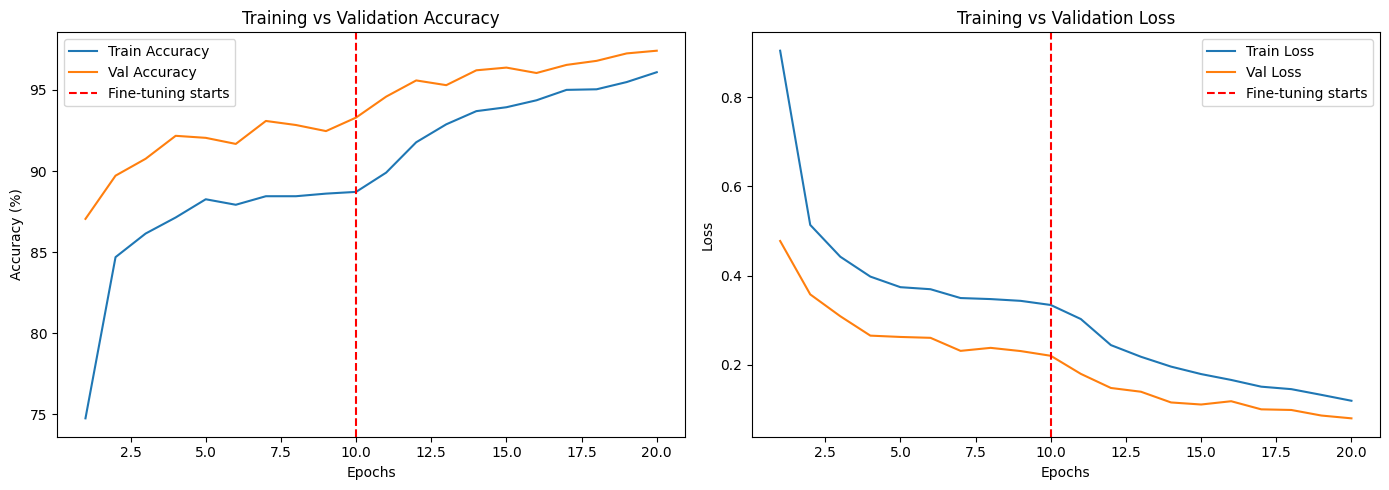

Curves saved!


In [12]:
import matplotlib.pyplot as plt

# Combine both phases
all_train_accs = p1_train_accs + p2_train_accs
all_val_accs = p1_val_accs + p2_val_accs
all_train_losses = p1_train_losses + p2_train_losses
all_val_losses = p1_val_losses + p2_val_losses

epochs_range = range(1, 21)

plt.figure(figsize=(14, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(epochs_range, all_train_accs, label='Train Accuracy')
plt.plot(epochs_range, all_val_accs, label='Val Accuracy')
plt.axvline(x=10, color='red', linestyle='--', label='Fine-tuning starts')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, all_train_losses, label='Train Loss')
plt.plot(epochs_range, all_val_losses, label='Val Loss')
plt.axvline(x=10, color='red', linestyle='--', label='Fine-tuning starts')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('accuracy_loss_curves.png', dpi=150)
plt.show()
print("Curves saved!")

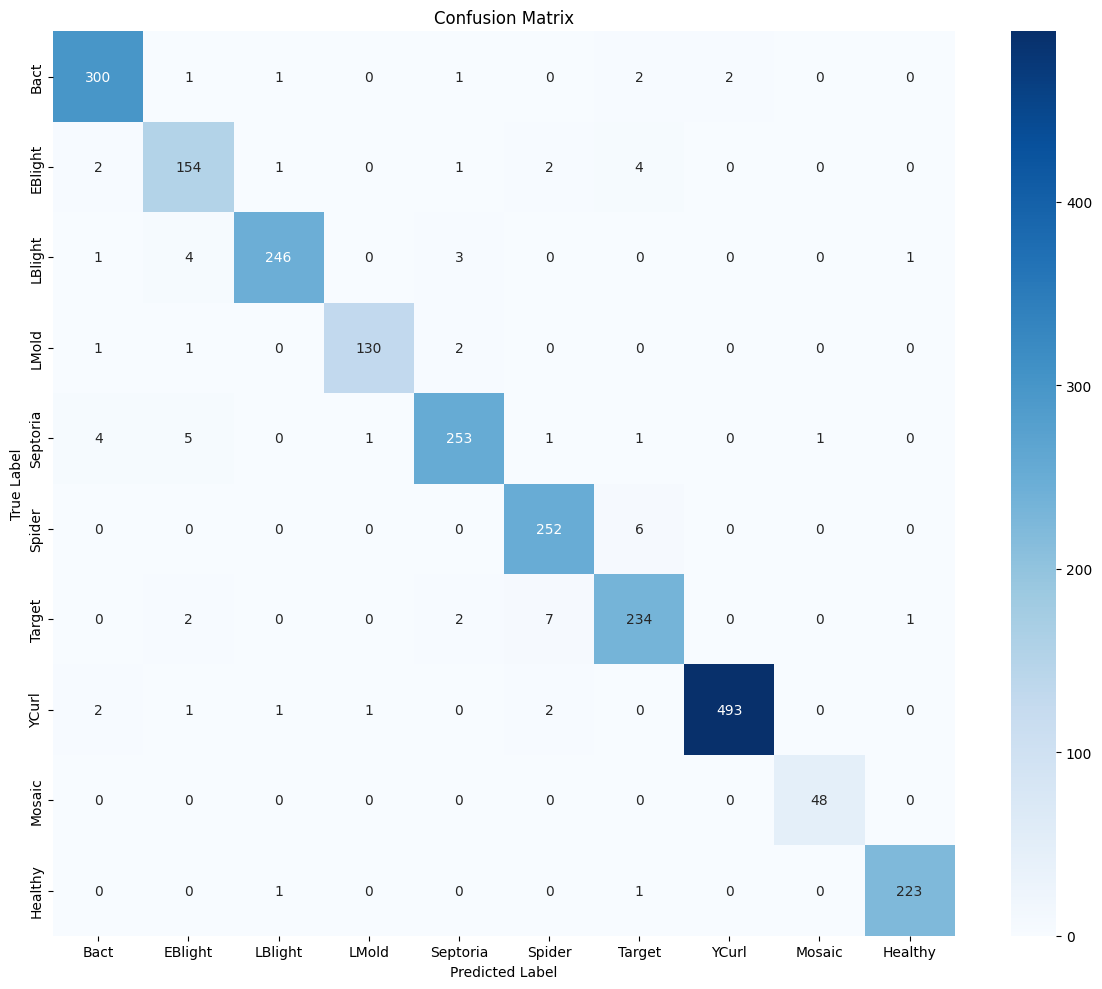

              precision    recall  f1-score   support

        Bact       0.97      0.98      0.97       307
     EBlight       0.92      0.94      0.93       164
     LBlight       0.98      0.96      0.97       255
       LMold       0.98      0.97      0.98       134
    Septoria       0.97      0.95      0.96       266
      Spider       0.95      0.98      0.97       258
      Target       0.94      0.95      0.95       246
       YCurl       1.00      0.99      0.99       500
      Mosaic       0.98      1.00      0.99        48
     Healthy       0.99      0.99      0.99       225

    accuracy                           0.97      2403
   macro avg       0.97      0.97      0.97      2403
weighted avg       0.97      0.97      0.97      2403



In [13]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

# Get predictions on test set
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
short_names = ['Bact', 'EBlight', 'LBlight', 'LMold',
               'Septoria', 'Spider', 'Target', 'YCurl',
               'Mosaic', 'Healthy']

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=short_names,
            yticklabels=short_names)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# Classification report
print(classification_report(all_labels, all_preds, target_names=short_names))

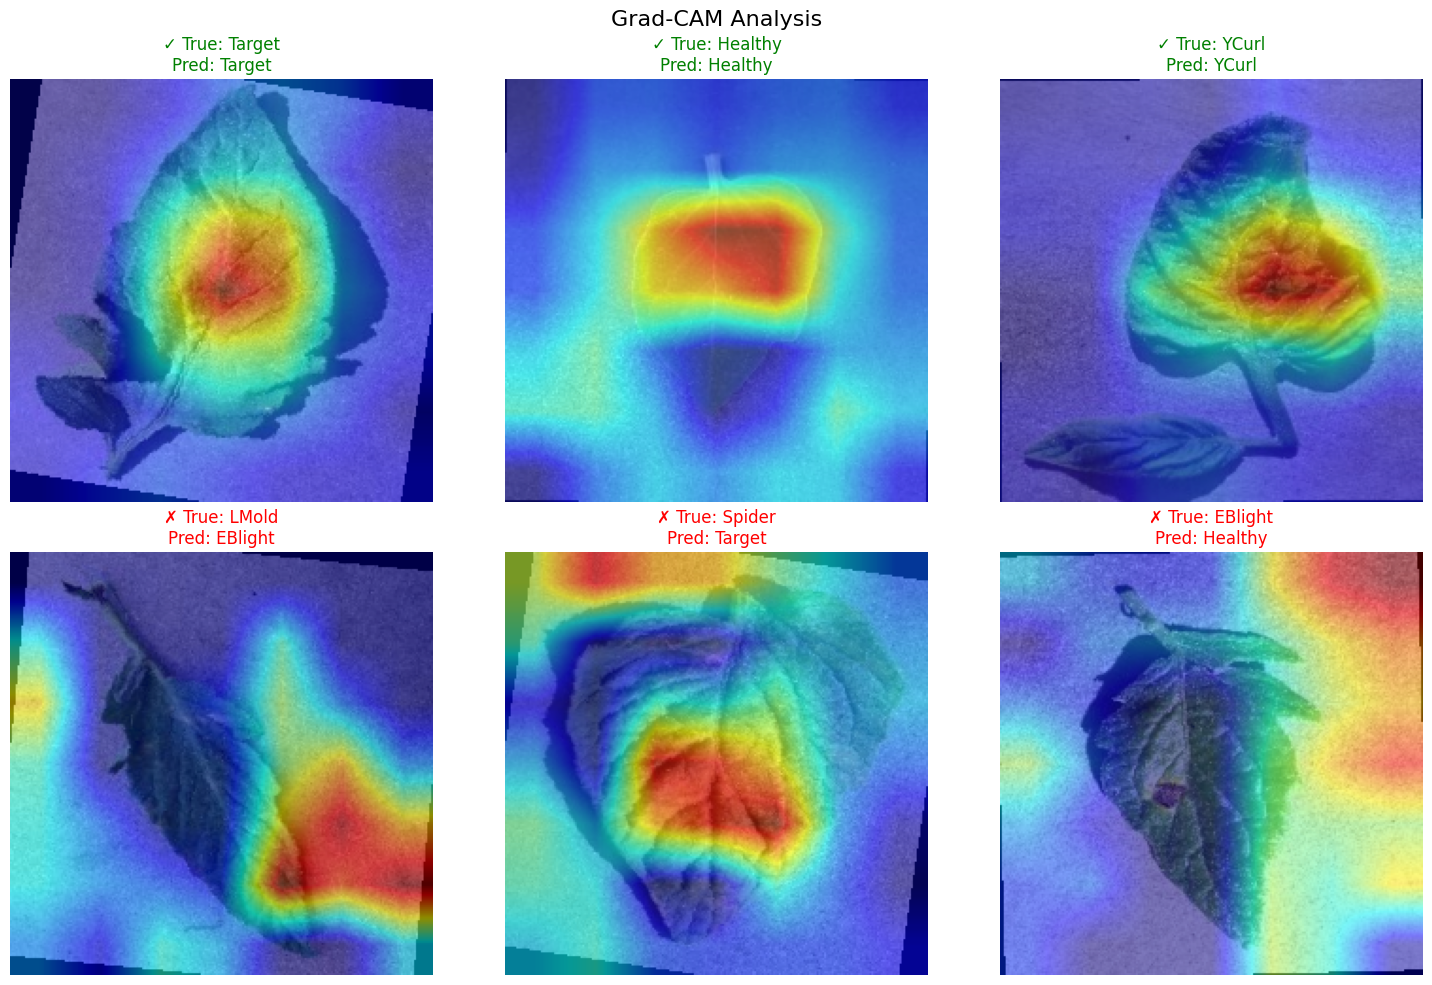

GradCAM saved!


In [14]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from torchvision import transforms
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch

# Target layer for EfficientNetB0
target_layer = [model.features[-1]]

# Initialize GradCAM
cam = GradCAM(model=model, target_layers=target_layer)

# Inverse normalize for display
inv_normalize = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)

# Get some test images
correct_imgs, correct_labels, correct_preds = [], [], []
wrong_imgs, wrong_labels, wrong_preds = [], [], []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)

        for i in range(len(labels)):
            if predicted[i] == labels[i] and len(correct_imgs) < 3:
                correct_imgs.append(images[i])
                correct_labels.append(labels[i].item())
                correct_preds.append(predicted[i].item())
            elif predicted[i] != labels[i] and len(wrong_imgs) < 3:
                wrong_imgs.append(images[i])
                wrong_labels.append(labels[i].item())
                wrong_preds.append(predicted[i].item())

        if len(correct_imgs) == 3 and len(wrong_imgs) == 3:
            break

# Plot GradCAM
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Grad-CAM Analysis', fontsize=16)

for idx in range(3):
    # Correct predictions
    img_tensor = correct_imgs[idx].unsqueeze(0)
    grayscale_cam = cam(input_tensor=img_tensor)
    img_display = inv_normalize(correct_imgs[idx]).cpu().permute(1,2,0).numpy()
    img_display = np.clip(img_display, 0, 1)
    cam_image = show_cam_on_image(img_display, grayscale_cam[0], use_rgb=True)
    axes[0][idx].imshow(cam_image)
    axes[0][idx].set_title(f'✓ True: {short_names[correct_labels[idx]]}\nPred: {short_names[correct_preds[idx]]}', color='green')
    axes[0][idx].axis('off')

    # Wrong predictions
    img_tensor = wrong_imgs[idx].unsqueeze(0)
    grayscale_cam = cam(input_tensor=img_tensor)
    img_display = inv_normalize(wrong_imgs[idx]).cpu().permute(1,2,0).numpy()
    img_display = np.clip(img_display, 0, 1)
    cam_image = show_cam_on_image(img_display, grayscale_cam[0], use_rgb=True)
    axes[1][idx].imshow(cam_image)
    axes[1][idx].set_title(f'✗ True: {short_names[wrong_labels[idx]]}\nPred: {short_names[wrong_preds[idx]]}', color='red')
    axes[1][idx].axis('off')

plt.tight_layout()
plt.savefig('gradcam_analysis.png', dpi=150)
plt.show()
print("GradCAM saved!")

In [15]:
# Save the model
torch.save(model.state_dict(), 'plant_disease_model.pth')
print("Model saved!")

# Final test accuracy
model.eval()
test_correct = 0
test_total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        test_total += labels.size(0)
        test_correct += predicted.eq(labels).sum().item()

test_acc = 100 * test_correct / test_total
print(f"Final Test Accuracy: {test_acc:.2f}%")

Model saved!
Final Test Accuracy: 97.25%


In [16]:
# Error Analysis
model.eval()
wrong_examples = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)

        for i in range(len(labels)):
            if predicted[i] != labels[i]:
                wrong_examples.append({
                    'true': labels[i].item(),
                    'pred': predicted[i].item()
                })

# Count most common mistakes
from collections import Counter
mistakes = Counter([(short_names[e['true']], short_names[e['pred']])
                    for e in wrong_examples])

print(f"Total wrong predictions: {len(wrong_examples)}")
print(f"\nTop 10 most common mistakes:")
for (true, pred), count in mistakes.most_common(10):
    print(f"  True: {true:12} → Predicted: {pred:12} | Count: {count}")

Total wrong predictions: 46

Top 10 most common mistakes:
  True: Target       → Predicted: Spider       | Count: 6
  True: LMold        → Predicted: Septoria     | Count: 6
  True: Spider       → Predicted: Target       | Count: 4
  True: EBlight      → Predicted: Target       | Count: 4
  True: Bact         → Predicted: Target       | Count: 3
  True: YCurl        → Predicted: Spider       | Count: 3
  True: EBlight      → Predicted: LBlight      | Count: 2
  True: Septoria     → Predicted: Bact         | Count: 2
  True: YCurl        → Predicted: Bact         | Count: 2
  True: Target       → Predicted: Healthy      | Count: 2
